# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Leann Vo

**Date:** 9/7/2026

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Question 1**

**Question 2**

In [32]:
df = pd.read_csv('./ForeignGifts_edu.csv')
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


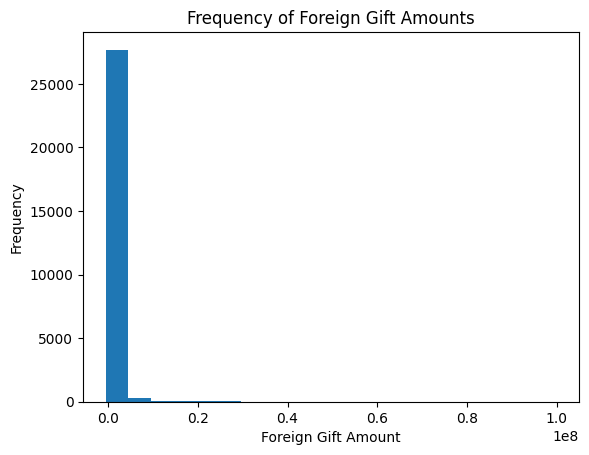

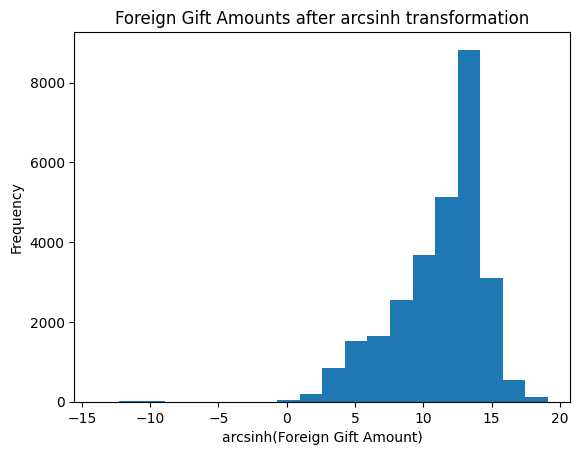

In [43]:
# 2. Foreign Gift Amount Histogram
df['Foreign Gift Amount'].hist(bins=20,grid=False) # **fix range to 0-40,000
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Frequency')
plt.title('Frequency of Foreign Gift Amounts')
plt.show()

df['Gift_arcsinh'] = np.arcsinh(df['Foreign Gift Amount'])
df['Gift_arcsinh'].hist(bins=20,grid=False)
plt.xlabel('arcsinh(Foreign Gift Amount)')
plt.ylabel('Frequency')
plt.title('Foreign Gift Amounts after arcsinh transformation')
plt.show()


In [ ]:
sns.violinplot(data = df, x = 'Foreign Gift Amount', y = 'Gift_arcsinh', fill=False, inner='quart')
plt.xlabel('Foreign Gift Amount')
plt.title('Violin Plot of Foreign Gift Amounts')
plt.show()

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7b3926147560> (for post_execute):


KeyboardInterrupt: 

Describe the variable and findings:

In [34]:
# 3. Gift Type Histogram

print(df['Gift Type'].value_counts())

total_gifts = len(df['Gift Type'])
contract_proportion = (df['Gift Type'] == 'Contract').sum() / total_gifts
real_estate_proportion = (df['Gift Type'] == 'Real Estate').sum() / total_gifts
monetary_proportion = (df['Gift Type'] == 'Monetary Gift').sum() / total_gifts
print('Proportion of Gifts that are Contracts:', contract_proportion)
print('Proportion of Gifts that are Real Estate:', real_estate_proportion)
print('Proportion of Gifts that are Monetary:', monetary_proportion)

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
Proportion of Gifts that are Contracts: 0.6120973742957372
Proportion of Gifts that are Real Estate: 0.00038978065979235324
Proportion of Gifts that are Monetary: 0.3875128450444704


Create a kernel density plot of the log of Foreign Gift Amount, and then a kernel density plot of the log of Foreign Gift Amount conditional on gift type. Do you notice any patterns?

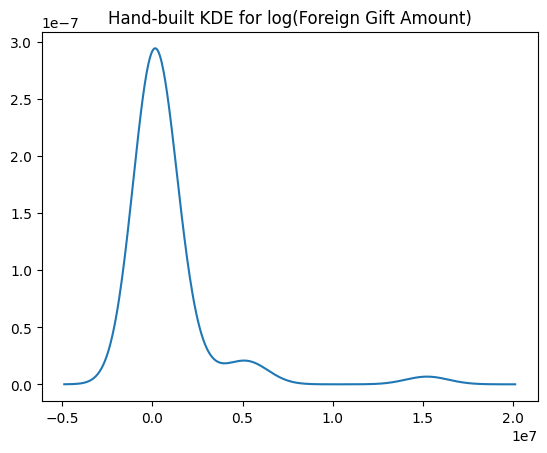

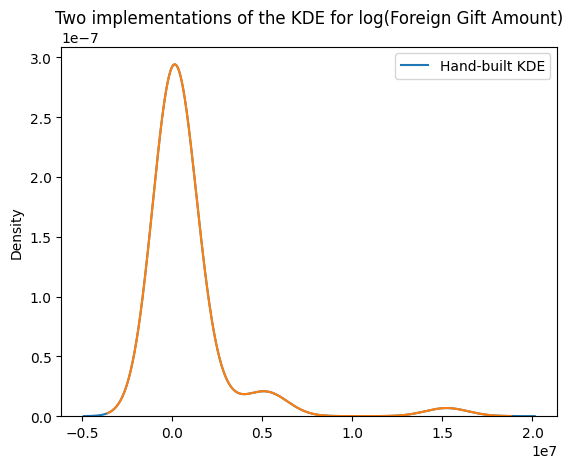

In [41]:
# 4. Kernel Density Plot for log(Foreign Gift Amount)
x = df['Foreign Gift Amount'].dropna().sample(50, random_state=10).to_numpy()

N = len(x)
sample_sd = np.std(x, ddof=1)
h_s = 1.06 * sample_sd * N**(-1/5)
grid = np.linspace(x.min() - 2 * sample_sd, x.max() + 2 * sample_sd, 500)

def normal_kernal(center, bandwidth):
  z = (grid - center) / bandwidth
  return np.exp(-(z**2) / 2) / (bandwidth * np.sqrt(2 * np.pi))

kde = sum(normal_kernal(value, h_s) for value in x) / N
ax = sns.lineplot(x=grid, y=kde)
ax.set(title='Hand-built KDE for log(Foreign Gift Amount)')
plt.show()
# **Add axis labels and fix title

# Check the implementation
ax = sns.lineplot(x=grid, y=kde, label='Hand-built KDE')
sns.kdeplot(x=x, bw_method='silverman', label='Seaborn KDE', ax=ax)
ax.set(title='Two implementations of the KDE for log(Foreign Gift Amount)')
plt.show()

In [ ]:
# 4-cont. Kernel Density Plot for log(Foreign Gift Amount) conditional on Gift Type


What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?

In [ ]:
# 5. Top 15 Countries with Most Gifts


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [36]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]